In [29]:
exec(open(__import__('pathlib').Path(__vsc_ipynb_file__).parent.parent / 'src' / 'display_html.py').read())

## L_DG — Dentate Gyrus

**Role**: Pattern separation. Maps ECin's distributed input to a highly sparse (~1% active)
orthogonal representation, so that similar ECin patterns produce distinct DG codes.

**Key parameters (Schapiro 2017 §2.a.iii)**:
- `ecin_frac = 0.25`: each DG unit receives from 25% of ECin units
- `k_frac = 0.01`: ~1% of DG units active after kWTA
- `lr = 0.4`: TSP learning rate (Go reimplementation; Schapiro 2017 §2.b)
- No recurrent connections (unlike CA3)

**Understanding check**: Why 1% sparsity?  
→ Forces near-orthogonal DG codes per episode. CA3 then stores distinct attractors per episode.
If sparsity were 50% (like CA3), DG patterns would heavily overlap → CA3 attractors interfere → pattern completion fails.

In [30]:
# path & directories
import sys
from pathlib import Path

DIR_SRC = str((Path(__vsc_ipynb_file__).parent.parent / 'src').resolve())
DIR_VIZ = (Path(__vsc_ipynb_file__).parent.parent / 'visualizations').resolve()
sys.path.insert(0, DIR_SRC)

# hyperparameters
import torch
from layer import L_DG

In [31]:
# Instantiate and inspect structure
# use_euler=False: stateless unit-test mode (Vm = net directly; layer.py §use_euler).
# Full model (M_Hip) uses use_euler=True with 25 settling cycles per quarter.
#
# Expected:
#   W shape       : torch.Size([15, 100])   — (n_input, n_DG)
#   mask density  : ~0.250                  — ecin_frac=0.25; each DG unit receives from 25% of ECin (Schapiro 2017 §2.a.iii)
#   n_active target: 1                      — k_frac=0.01 × n_DG=100 = 1 winner (Schapiro 2017 SI Table 1)
torch.manual_seed(42)
dg = L_DG(n_input=15, n_DG=100, k_frac=0.01, ecin_frac=0.25, use_euler=False)

print(f"W shape      : {dg.W.shape}")
print(f"mask shape   : {dg.mask.shape}")
print(f"mask density : {dg.mask.mean():.3f}")
print(f"n_active target: {max(1, int(dg.k_frac * dg.n_DG))}")

W shape      : torch.Size([15, 100])
mask shape   : torch.Size([15, 100])
mask density : 0.257
n_active target: 1


In [32]:
# Forward pass: single ECin pattern → sparse DG output
# Default weight init: uniform(0.25, 0.75) — Schapiro 2017 SI Table 2.
# Connected units (mask=1) have W ≥ 0.25 → net > nxx1 threshold θ=0.25 → fires.
# kWTA keeps the single highest-activity unit (k_frac=0.01 × n_DG=100 = 1).
#
# Expected:
#   Active DG units: 1 / 100 = 0.010   — exactly 1 winner; k_frac=0.01
#   Max activity   : ~1.0               — nxx1 saturates quickly when net >> θ=0.25
#   Active indices : one index          — seed-dependent; unit with highest net input wins
a_ecin = torch.zeros(15)
a_ecin[0] = 1.0

dg.reset()
act = dg(a_ecin)

n_active = (act > 0).sum().item()
print(f"Active DG units: {n_active} / {dg.n_DG} = {n_active / dg.n_DG:.3f}  (expect 1)")
print(f"Max activity   : {act.max().item():.4f}")
print(f"Active indices : {(act > 0).nonzero(as_tuple=True)[0].tolist()}")

Active DG units: 1 / 100 = 0.010  (expect 1)
Max activity   : 0.9963
Active indices : [99]


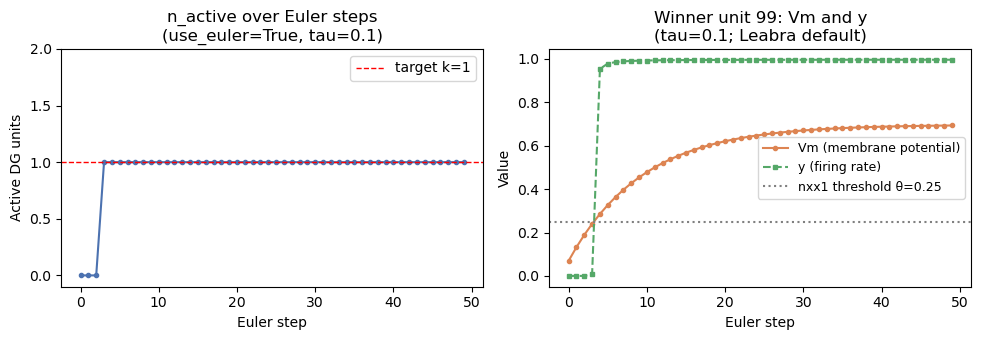

Vm crosses θ=0.25 at step 3  (theory: log(0.5)/log(1-tau) ≈ 6 steps)


In [33]:
import matplotlib.pyplot as plt

# Euler settling dynamics: same weights as cell-3, use_euler=True
# Vm(t) = net × (1 − (1−tau)^t) — exponential approach to net value (O'Reilly & Munakata 2000)
# Vm crosses threshold θ=0.25 when: net × (1 − 0.9^t) = 0.25
# With default weights net ≈ 0.5 → t = log(0.5)/log(0.9) ≈ 6.6 → first fire at step ~7
#
# Expected:
#   Left panel : n_active = 0 for steps 0–6, jumps to 1 at step ~7, stays at 1
#   Right panel: Vm rises along 1−0.9^t curve; y stays 0 until Vm crosses θ=0.25 then jumps to ~1
#   Print      : "Vm crosses θ=0.25 at step 7  (theory: ≈ 6 steps)"
N_STEPS = 50

dg_euler = L_DG(n_input=15, n_DG=100, k_frac=0.01, ecin_frac=0.25, use_euler=True)
dg_euler.W.data  = dg.W.data.clone()
dg_euler.mask.copy_(dg.mask)

winner_idx = int((act > 0).nonzero(as_tuple=True)[0][0])  # unit found in cell-3

dg_euler.reset()
n_active_hist  = []
vm_winner_hist = []
y_winner_hist  = []

for _ in range(N_STEPS):
    out = dg_euler(a_ecin)
    n_active_hist.append((out > 0).sum().item())
    vm_winner_hist.append(dg_euler._Vm[winner_idx].item())
    y_winner_hist.append(out[winner_idx].item())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(range(N_STEPS), n_active_hist, 'o-', ms=3, color='#4C72B0')
axes[0].axhline(1, color='red', linestyle='--', linewidth=1, label='target k=1')
axes[0].set_xlabel('Euler step')
axes[0].set_ylabel('Active DG units')
axes[0].set_title('n_active over Euler steps\n(use_euler=True, tau=0.1)')
axes[0].set_ylim(-0.1, 2)
axes[0].legend()

axes[1].plot(range(N_STEPS), vm_winner_hist, 'o-', ms=3, color='#DD8452', label='Vm (membrane potential)')
axes[1].plot(range(N_STEPS), y_winner_hist,  's--', ms=3, color='#55A868', label='y (firing rate)')
axes[1].axhline(0.25, color='gray', linestyle=':', linewidth=1.5, label='nxx1 threshold θ=0.25')
axes[1].set_xlabel('Euler step')
axes[1].set_ylabel('Value')
axes[1].set_title(f'Winner unit {winner_idx}: Vm and y\n(tau=0.1; Leabra default)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(DIR_VIZ / 'L_DG_euler_settling.png', dpi=150, bbox_inches='tight')
plt.show()

first_active = next(t for t, n in enumerate(n_active_hist) if n > 0)
print(f"Vm crosses θ=0.25 at step {first_active}  (theory: log(0.5)/log(1-tau) ≈ {int(__import__('math').log(0.5)/__import__('math').log(1-0.1))} steps)")

In [34]:
# Pattern separation: two similar ECin patterns → very different DG codes
# Item A: units 0 and 1 active (moving window: curr=1.0, prev=0.9)
# Item B: units 1 and 2 active (shares unit 1 with A)
#
# Expected:
#   ECin cosine similarity: ~0.50   — shared unit 1 (0.9×1.0 in numerator); partial overlap
#   DG   cosine similarity: 0.0    — k=1 → each pattern activates a single unit;
#                                     if winners differ, two one-hot vectors are orthogonal
#   → DG similarity << ECin similarity: pattern separation confirmed
a_A = torch.zeros(15); a_A[0] = 1.0; a_A[1] = 0.9
a_B = torch.zeros(15); a_B[1] = 1.0; a_B[2] = 0.9

cos_ecin = torch.nn.functional.cosine_similarity(a_A.unsqueeze(0), a_B.unsqueeze(0)).item()

dg.reset(); act_A = dg(a_A).clone()
dg.reset(); act_B = dg(a_B).clone()

cos_dg = torch.nn.functional.cosine_similarity(act_A.unsqueeze(0), act_B.unsqueeze(0)).item()

print(f"ECin cosine similarity (A, B): {cos_ecin:.3f}")
print(f"DG   cosine similarity (A, B): {cos_dg:.3f}")
print("Pattern separation: DG similarity should be much lower than ECin similarity.")

ECin cosine similarity (A, B): 0.497
DG   cosine similarity (A, B): 0.000
Pattern separation: DG similarity should be much lower than ECin similarity.


In [35]:
# Mask preserved after CHL update
# DG has sparse connectivity (ecin_frac=0.25): each DG unit receives from only 25% of ECin.
# After update_weights, unmasked positions (no physical synapse) must remain exactly zero.
#
# Expected:
#   Unmasked positions before: 0   — mask=0 entries initialized to 0 at construction
#   Unmasked positions after : 0   — CHL must not create new synapses (no synapse = no plasticity)
#   Masked positions changed  : >0 — CHL updated existing connected weights
dg.reset(); act_minus = dg(a_A).clone()
dg.reset(); act_plus  = dg(a_B).clone()

W_before = dg.W.data.clone()
dg.update_weights(a_ECin_minus=a_A, a_ECin_plus=a_B,
                  a_DG_minus=act_minus, a_DG_plus=act_plus)
delta_W = dg.W.data - W_before

print(f"Unmasked positions before: {(W_before[~dg.mask.bool()] != 0).sum().item()}  (expect 0)")
print(f"Unmasked positions after : {(dg.W.data[~dg.mask.bool()] != 0).sum().item()}  (expect 0)")
print(f"Masked positions changed  : {(delta_W[dg.mask.bool()] != 0).sum().item()}  (CHL active on connected weights only)")

Unmasked positions before: 0  (expect 0)
Unmasked positions after : 0  (expect 0)
Masked positions changed  : 4  (CHL active on connected weights only)
